In [69]:
from sklearn.preprocessing import StandardScaler
from utils.evaluation import *
from utils.load_data import load_processed_data
from models.dnn import DNN
from models.linear_regression import LinearRegressionSklearn 
import torch
from torch.utils.data import DataLoader, Dataset

## Load data

In [70]:
data_path = '../data/processed'
X_train, X_val, X_test, y_train, y_val, y_test = load_processed_data(data_path)

X_train shape: torch.Size([2437, 30]), y_train shape: torch.Size([2437, 1])
X_val shape: torch.Size([305, 30]), y_val shape: torch.Size([305, 1])
X_test shape: torch.Size([305, 30]), y_test shape: torch.Size([305, 1])


In [71]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [72]:
batch_size = 64

train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training and Evaluation

#### Hyperparameters

In [ ]:
epochs = 300
learning_rate = 0.01
dropout = 0.1
batch_norm = True
l2_lambda = 0
weight_decay = 0.001
grad_clip = False
activation = 'leaky_relu'
momentum = 0.9

In [74]:
def pipeline(
        model, 
        epochs=50, 
        verbose=True, 
        early_stopping=False, 
        patience=10, 
        grad_clip=True, 
        title=None,
):
    train_losses, val_losses = model.fit(
        train_loader, 
        val_loader, 
        epochs=epochs, 
        verbose=verbose, 
        early_stopping=early_stopping, 
        patience=patience, 
        grad_clip=grad_clip
    )
    test_model(model, X_test, y_test)
    if title is None:
        title = f'{model.__class__.__name__}'
    plot_loss(train_losses, val_losses, log=True, title=title)

### Linear Regression

In [75]:
lr = LinearRegressionSklearn()
lr.fit(X_train, y_train)
test_model(lr, X_test, y_test)


=========== Model Evaluation ===========
Mean Absolute Error (MAE): 10.3989
Mean Squared Error (MSE): 188.0138
R^2 Score: 0.7751


### DNN-16

In [76]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation, 
    weight_decay=weight_decay,
    momentum=momentum,
)
dnn_16.model

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 147.2251, Val Loss: 226.2312
Epoch [60/300], Train Loss: 133.7282, Val Loss: 195.7094
Epoch [90/300], Train Loss: 124.9794, Val Loss: 195.1640
Epoch [120/300], Train Loss: 128.2146, Val Loss: 253.8308
Epoch [150/300], Train Loss: 115.8749, Val Loss: 243.1474
Epoch [180/300], Train Loss: 114.2173, Val Loss: 203.9719
Epoch [210/300], Train Loss: 126.1245, Val Loss: 186.6833
Epoch [240/300], Train Loss: 120.4258, Val Loss: 176.5173
Epoch [270/300], Train Loss: 121.4456, Val Loss: 179.6941
Epoch [300/300], Train Loss: 129.2468, Val Loss: 185.9710

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 9.6881
Mean Squared Error (MSE): 175.4865
R^2 Score: 0.7901


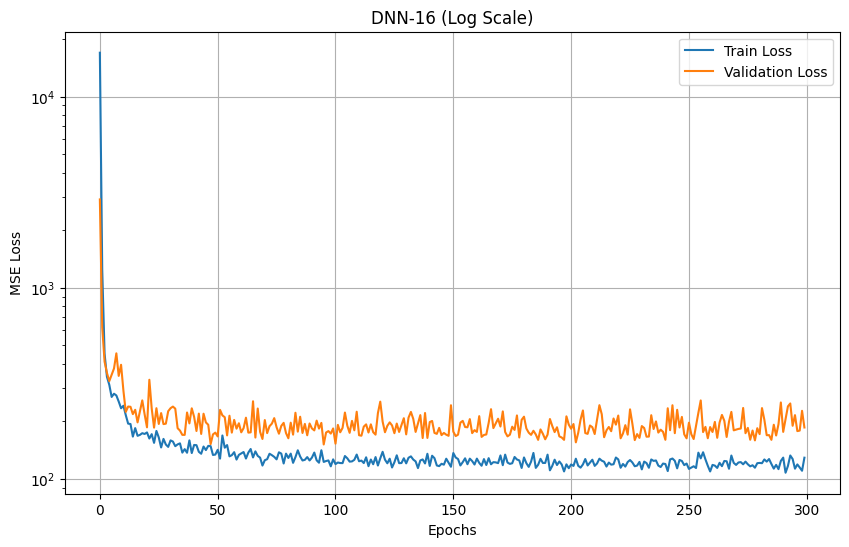

In [77]:
pipeline(dnn_16, epochs=epochs, title='DNN-16')

## DNN-30-8

In [78]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=30, out_features=30, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=30, out_features=8, bias=True)
  (3): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (4): LeakyReLU(negative_slope=0.01)
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [30/300], Train Loss: 1092.5908, Val Loss: 293.0523
Epoch [60/300], Train Loss: 656.4018, Val Loss: 206.9765
Epoch [90/300], Train Loss: 422.6220, Val Loss: 171.1514
Epoch [120/300], Train Loss: 312.1157, Val Loss: 239.7376
Epoch [150/300], Train Loss: 296.7962, Val Loss: 171.3206
Epoch [180/300], Train Loss: 254.0571, Val Loss: 145.5701
Epoch [210/300], Train Loss: 224.9097, Val Loss: 198.8354
Epoch [240/300], Train Loss: 213.1663, Val Loss: 155.7702
Epoch [270/300], Train Loss: 225.3066, Val Loss: 163.7394
Epoch [300/300], Train Loss: 218.3805, Val Loss: 171.1675

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 9.2646
Mean Squared Error (MSE): 151.9939
R^2 Score: 0.8182


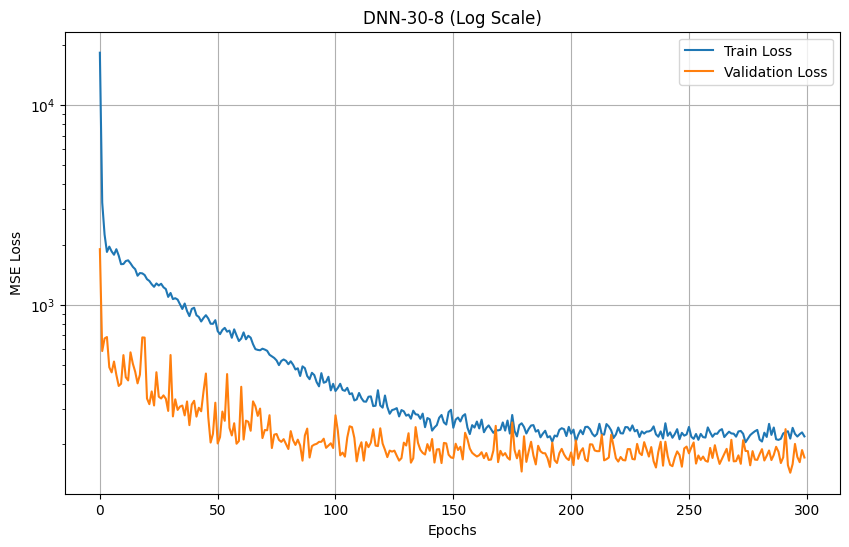

In [79]:
pipeline(dnn_30_8, epochs=epochs, title='DNN-30-8')

## DNN-30-16-8

In [80]:
dnn_30_16_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)

Epoch [30/300], Train Loss: 1224.9740, Val Loss: 329.3803
Epoch [60/300], Train Loss: 692.6600, Val Loss: 241.0132
Epoch [90/300], Train Loss: 446.0435, Val Loss: 199.1233
Epoch [120/300], Train Loss: 360.1811, Val Loss: 177.4583
Epoch [150/300], Train Loss: 270.5213, Val Loss: 198.9658
Epoch [180/300], Train Loss: 233.3343, Val Loss: 227.2141
Epoch [210/300], Train Loss: 226.1411, Val Loss: 184.7811
Epoch [240/300], Train Loss: 269.7531, Val Loss: 154.4163
Epoch [270/300], Train Loss: 231.0692, Val Loss: 168.1581
Epoch [300/300], Train Loss: 220.2137, Val Loss: 161.4572

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 8.3510
Mean Squared Error (MSE): 128.0068
R^2 Score: 0.8469


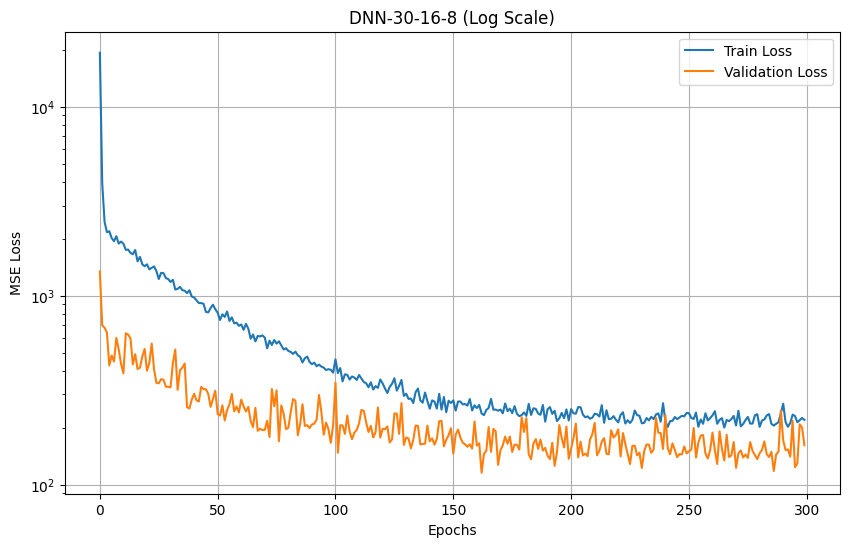

In [81]:
pipeline(dnn_30_16_8, epochs=epochs, title='DNN-30-16-8')

## DNN-30-16-8-4

In [82]:
dnn_30_16_8_4 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8, 4],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)

Epoch [30/300], Train Loss: 1055.8185, Val Loss: 480.5799
Epoch [60/300], Train Loss: 454.1430, Val Loss: 226.7848
Epoch [90/300], Train Loss: 327.0613, Val Loss: 234.6678
Epoch [120/300], Train Loss: 315.3847, Val Loss: 252.4870
Epoch [150/300], Train Loss: 304.3337, Val Loss: 248.5400
Epoch [180/300], Train Loss: 326.5112, Val Loss: 179.8308
Epoch [210/300], Train Loss: 296.3696, Val Loss: 224.6087
Epoch [240/300], Train Loss: 309.1978, Val Loss: 179.3659
Epoch [270/300], Train Loss: 301.7279, Val Loss: 197.7317
Epoch [300/300], Train Loss: 277.1005, Val Loss: 204.5202

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 9.8312
Mean Squared Error (MSE): 189.3518
R^2 Score: 0.7735


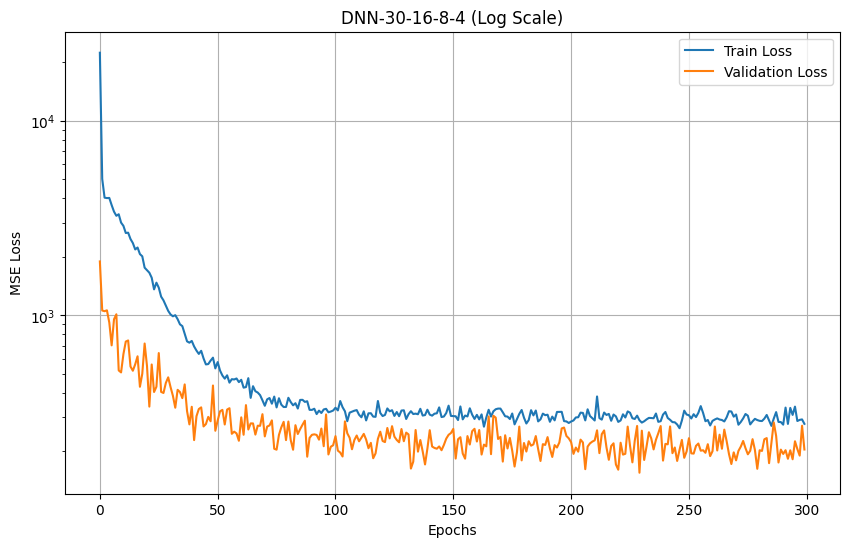

In [83]:
pipeline(dnn_30_16_8_4, epochs=epochs, title='DNN-30-16-8-4')

## Custom DNN

In [84]:
custom_dnn = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[128, 64, 32, 16],
    output_dim=1,
    lr=learning_rate,
    dropout=dropout,
    batch_norm=batch_norm,
    l2_lambda=l2_lambda,
    activation=activation,
    weight_decay=weight_decay,
    momentum=momentum,
)

Epoch [30/300], Train Loss: 886.7866, Val Loss: 307.9212
Epoch [60/300], Train Loss: 689.1955, Val Loss: 261.2989
Epoch [90/300], Train Loss: 570.8787, Val Loss: 225.6386
Epoch [120/300], Train Loss: 466.5966, Val Loss: 181.5390
Epoch [150/300], Train Loss: 388.8330, Val Loss: 165.8267
Epoch [180/300], Train Loss: 317.9625, Val Loss: 213.5789
Epoch [210/300], Train Loss: 271.6692, Val Loss: 157.7650
Epoch [240/300], Train Loss: 256.0954, Val Loss: 147.7426
Epoch [270/300], Train Loss: 234.3059, Val Loss: 157.6612
Epoch [300/300], Train Loss: 204.4164, Val Loss: 168.1633

=========== Model Evaluation ===========
Mean Absolute Error (MAE): 8.7309
Mean Squared Error (MSE): 141.0866
R^2 Score: 0.8312


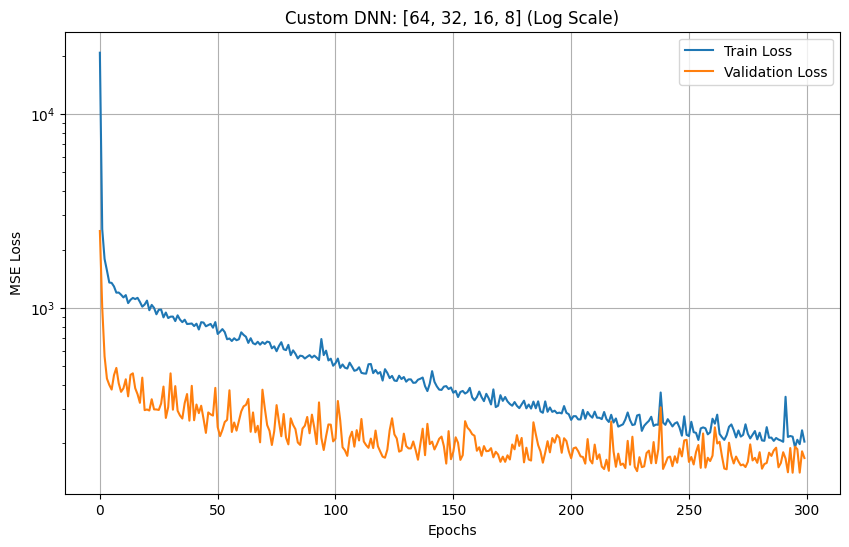

In [85]:
pipeline(custom_dnn, epochs=epochs, title='Custom DNN: [64, 32, 16, 8]')